In [1]:
from langgraph.graph import StateGraph
from typing import TypedDict, Dict, Any
from IPython.display import display, Image

class IntentPriorityState(TypedDict):
    message: str
    department: str
    priority: str

def router1(state : Dict[str,Any]):
    return state

def router2(state : Dict[str,Any]):
    return state

def billing(state : Dict[str,Any]):
    state['department'] = 'Billing Department'
    return state

def technical(state : Dict[str,Any]):
    state['department'] = 'Technical Department'
    return state

def delivery(state : Dict[str,Any]):
    state['department'] = 'Delivery Department'
    return state

def general(state : Dict[str,Any]):
    state['department'] = 'General Department'
    return state

def highpriority(state : Dict[str,Any]):
    state['priority'] = 'High Priority'
    return state

def lowpriority(state : Dict[str,Any]):
    state['priority'] = 'Low Priority'
    return state

def check_logic1(state):
    msg = state['message'].lower()
    
    if 'refund' in msg or 'payment' in msg:
        return 'Billing'
    elif 'error' in msg or 'not working' in msg:
        return 'Technical'
    elif 'delayed' in msg or 'delivery' in msg:
        return 'Delivery'
    else:
        return 'General'

def check_logic2(state):
    msg = state['message'].lower()
    
    if 'urgent' in msg or 'immediately' in msg or 'anger' in msg or 'complaint' in msg or 'asap' in msg:
        return 'High Priority'
    else:
        return 'Low Priority'

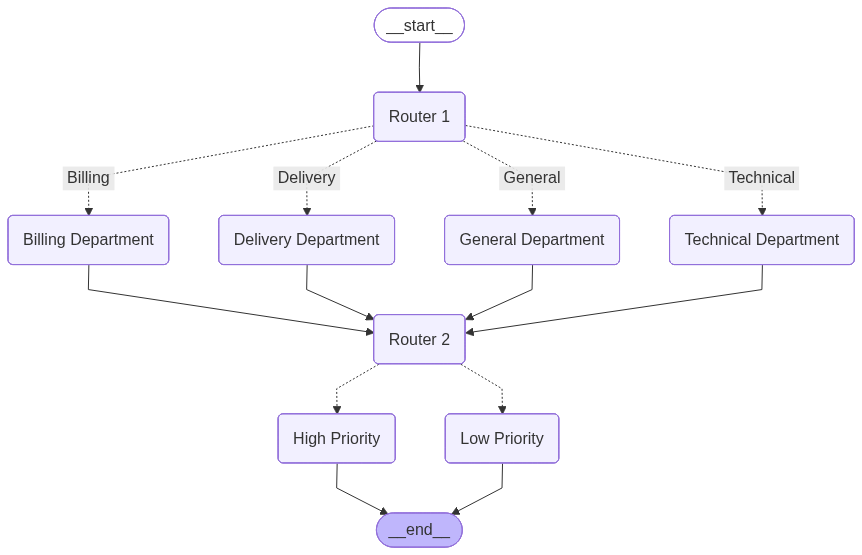

In [2]:
builder = StateGraph(IntentPriorityState)
builder.add_node('Router 1', router1)
builder.add_node('Billing Department', billing)
builder.add_node('Technical Department', technical)
builder.add_node('Delivery Department', delivery)
builder.add_node('General Department', general)
builder.add_node('Router 2', router2)
builder.add_node('High Priority', highpriority)
builder.add_node('Low Priority', lowpriority)

builder.set_entry_point('Router 1')

builder.add_conditional_edges('Router 1', check_logic1, {
    'Billing':'Billing Department',
    'Technical':'Technical Department',
    'Delivery':'Delivery Department',
    'General':'General Department'
})
builder.add_edge('Billing Department', 'Router 2')
builder.add_edge('Technical Department', 'Router 2')
builder.add_edge('Delivery Department', 'Router 2')
builder.add_edge('General Department', 'Router 2')
builder.add_conditional_edges('Router 2', check_logic2,{
    'High Priority' : 'High Priority',
    'Low Priority' : 'Low Priority'
})
    
builder.set_finish_point('High Priority')
builder.set_finish_point('Low Priority')

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization failed:", e)

In [3]:
customer_input = 'My order is delayed, I need action immediately'
result = graph.invoke({'message':customer_input})
print('Department: ', result['department'])
print('\nPriority: ', result['priority'])

Department:  Delivery Department

Priority:  High Priority
